Cell 1: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Cell 2: Load the Dataset

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/CSE303/Project/insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


Cell 3: Basic Information & Missing Values

In [8]:
print(df.shape)
print(df.info())
print("Missing Values:\n", df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())

(1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
Missing Values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Duplicate Rows: 1


Cell 4: Drop Duplicates

In [9]:
# Remove duplicates
df.drop_duplicates(inplace=True)

Cell 5: Data Cleaning

In [10]:
# Drop columns with more than 40% missing values
threshold = len(df) * 0.4
df.dropna(thresh=threshold, axis=1, inplace=True)

# Fill remaining missing values
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)

Cell 6: Label Encoding for Categorical Variables

In [11]:
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

Cell 7: Correlation MatrixCell 7: Correlation Matrix

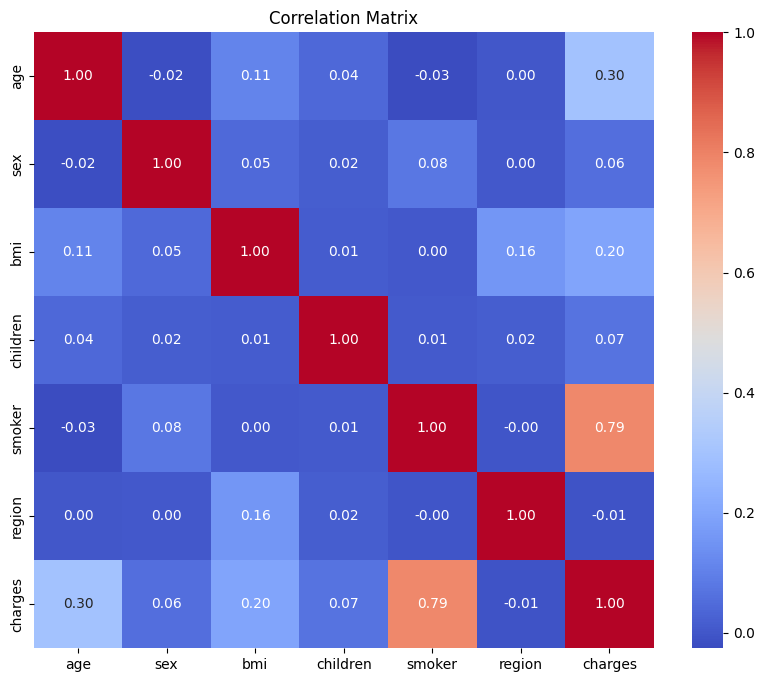

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Cell 8: Countplot (Categorical Distribution)

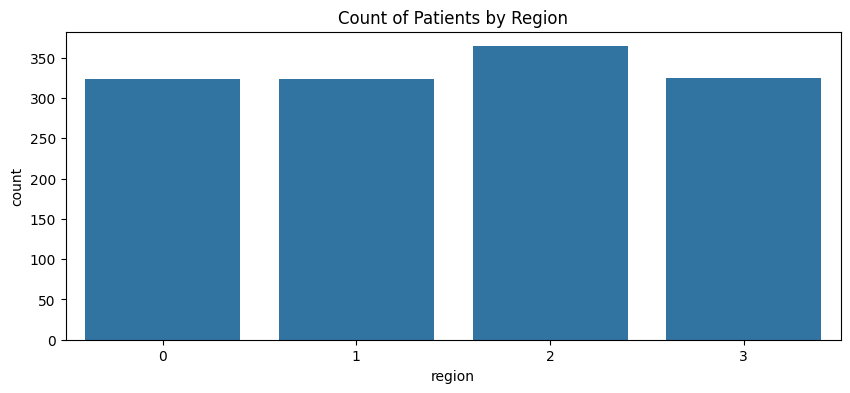

In [13]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='region') # You can change 'region' to 'children' if preferred
plt.title("Count of Patients by Region")
plt.show()

Cell 9: Histplot (Target Distribution)

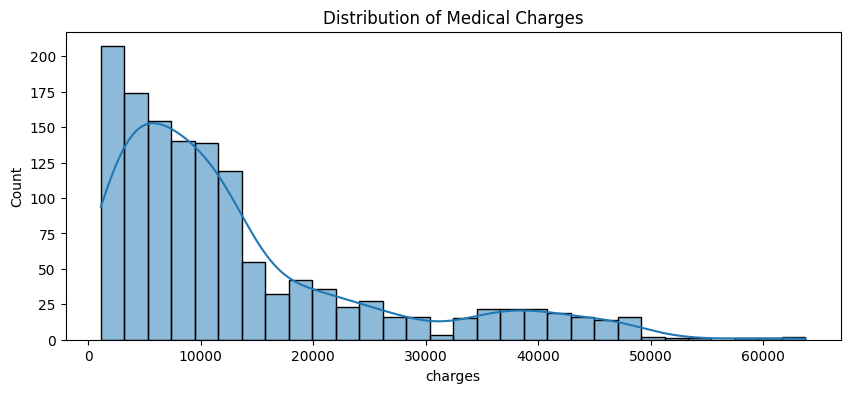

In [14]:
plt.figure(figsize=(10, 4))
sns.histplot(df['charges'], bins=30, kde=True)
plt.title("Distribution of Medical Charges")
plt.show()

Cell 10: Pie Chart

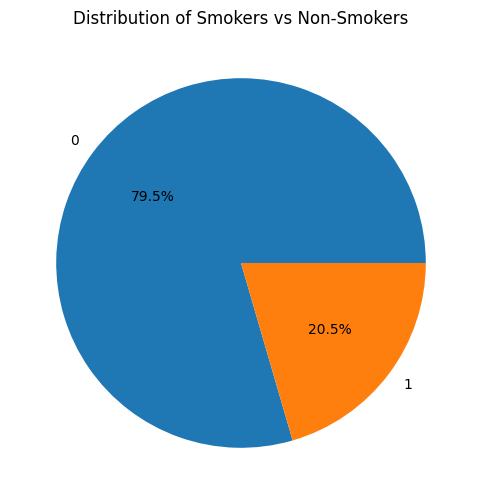

In [15]:
plt.figure(figsize=(6, 6))
df['smoker'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Distribution of Smokers vs Non-Smokers")
plt.ylabel('')
plt.show()

Cell 11: Scatter Plot

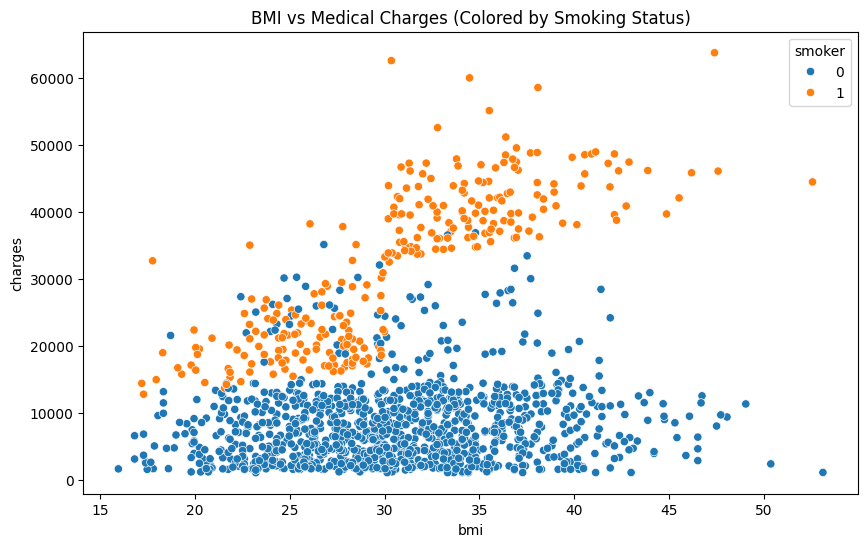

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title("BMI vs Medical Charges (Colored by Smoking Status)")
plt.show()

Cell 12: Feature Engineering (Binary Classification Target)

In [17]:
# Convert continuous 'charges' into a binary target based on the median
median_charges = df['charges'].median()
df['HighCharges'] = (df['charges'] > median_charges).astype(int)

Cell 13: Feature and Target Separation

In [18]:
X = df.drop(['charges', 'HighCharges'], axis=1)
y = df['HighCharges']

Cell 14: Feature Scaling

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Cell 15: Train-Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

Cell 16: Logistic Regression Model

In [21]:
log_model = LogisticRegression(max_iter=1000, solver='liblinear')
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9104477611940298
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.89      0.91       132
           1       0.89      0.93      0.91       136

    accuracy                           0.91       268
   macro avg       0.91      0.91      0.91       268
weighted avg       0.91      0.91      0.91       268



Cell 17: Logistic Regression Metrics Breakdown

In [22]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
specificity = tn / (tn + fp)
f1 = 2 * (precision * recall) / (precision + recall)
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print(f"TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")
print(f"False Negative Rate (FNR): {fnr:.4f}")

TP: 127, TN: 117, FP: 15, FN: 9
Accuracy: 0.9104
Precision: 0.8944
Recall (Sensitivity): 0.9338
Specificity: 0.8864
F1 Score: 0.9137
False Positive Rate (FPR): 0.1136
False Negative Rate (FNR): 0.0662


Cell 18: Logistic Regression Confusion Matrix Heatmap

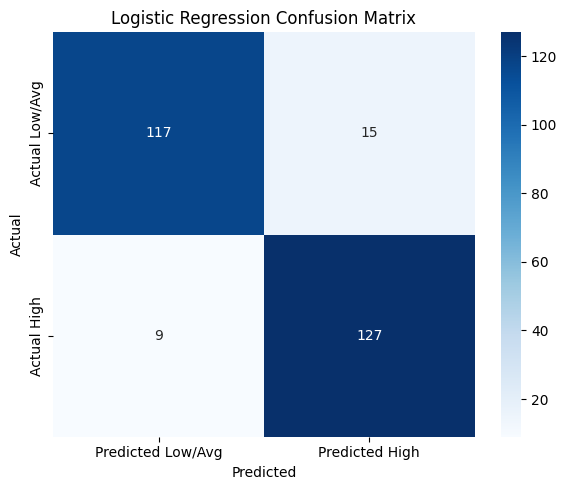

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Low/Avg', 'Predicted High'],
            yticklabels=['Actual Low/Avg', 'Actual High'])
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Cell 19: Random Forest Classifier Model

In [24]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9328358208955224
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.93       132
           1       0.95      0.92      0.93       136

    accuracy                           0.93       268
   macro avg       0.93      0.93      0.93       268
weighted avg       0.93      0.93      0.93       268



Cell 20: Random Forest Metrics Breakdown

In [25]:
rf_cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix (Random Forest):\n", rf_cm)

tn, fp, fn, tp = rf_cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
specificity = tn / (tn + fp)
f1 = 2 * (precision * recall) / (precision + recall)
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print(f"TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")
print(f"False Negative Rate (FNR): {fnr:.4f}")

Confusion Matrix (Random Forest):
 [[125   7]
 [ 11 125]]
TP: 125, TN: 125, FP: 7, FN: 11
Accuracy: 0.9328
Precision: 0.9470
Recall (Sensitivity): 0.9191
Specificity: 0.9470
F1 Score: 0.9328
False Positive Rate (FPR): 0.0530
False Negative Rate (FNR): 0.0809


Cell 21: Random Forest Confusion Matrix Heatmap

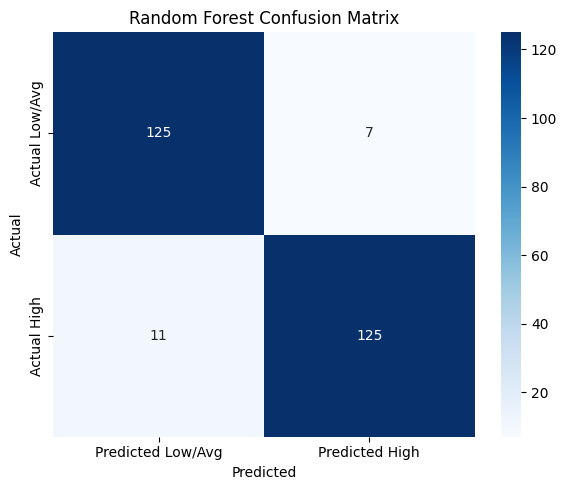

In [26]:
plt.figure(figsize=(6, 5))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Low/Avg', 'Predicted High'],
            yticklabels=['Actual Low/Avg', 'Actual High'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()